<a href="https://colab.research.google.com/github/Yobapatrick/projet-cv/blob/main/projet_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 50,331,648 || all params: 3,871,411,200 || trainable%: 1.3001
Début de l'entraînement...


Step,Training Loss,Validation Loss
50,0.273500,0.220199
100,0.143000,0.156199
150,0.139400,0.140046
200,0.153500,0.131034
250,0.133100,0.125333
300,0.084800,0.124509


Step,Training Loss,Validation Loss
50,0.273500,0.220199
100,0.143000,0.156199
150,0.139400,0.140046
200,0.153500,0.131034
250,0.133100,0.125333
300,0.084800,0.124509
350,0.086600,0.119431
400,0.161100,0.117870
450,0.116900,0.115078
500,0.121400,0.113049


Exception ignored in: <function _xla_gc_callback at 0x7f3969ef9580>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 



✅ Terminé. Adapters LoRA sauvegardés dans: /content/drive/MyDrive/projet_cv/projet-cv/model/cv-lora

Plotting training metrics...


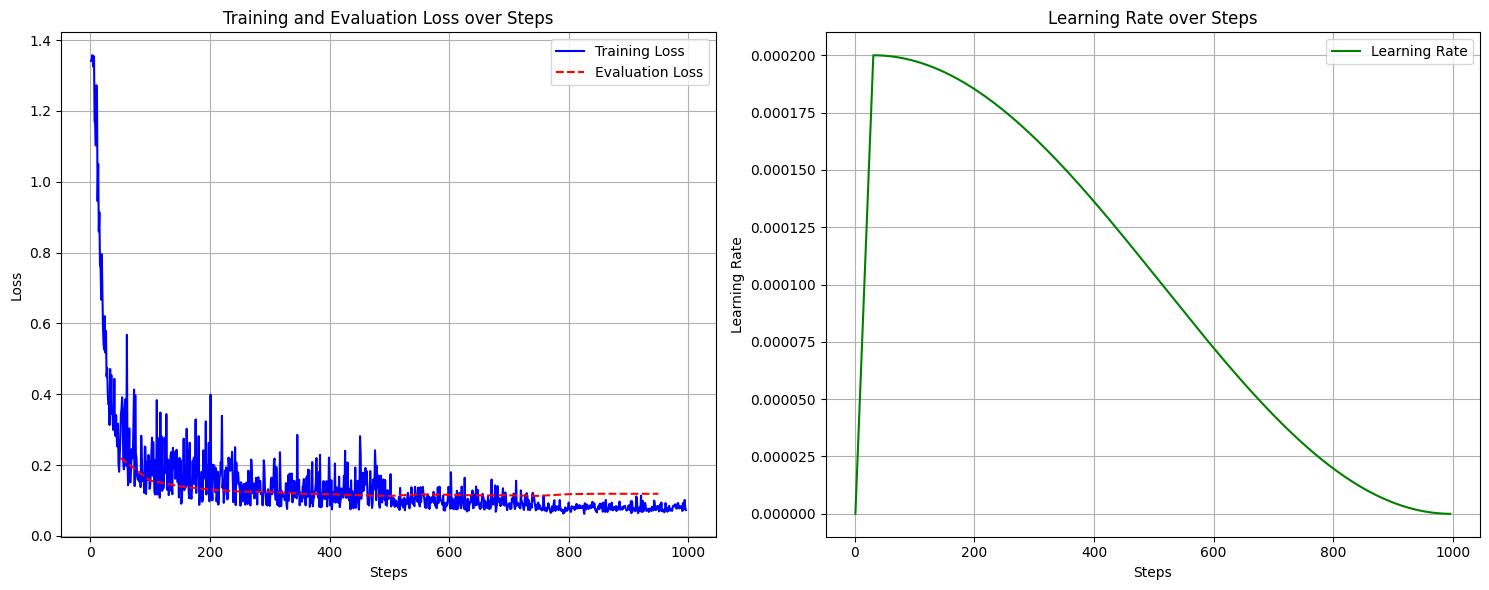

In [ ]:
!pip install trl
!pip install matplotlib
!pip install -U bitsandbytes

import os
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
import matplotlib.pyplot as plt



# On forcel'utilisation de bf16
os.environ["ACCELERATE_MIXED_PRECISION"] = "bf16"
os.environ["TORCH_DTYPE"] = "bfloat16"



# On utilise le chemin du drive que nous avons monté
PATH_PROJET = "/content/drive/MyDrive/projet_cv/projet-cv"
DOSSIER_CACHE = os.path.join(PATH_PROJET, "cache")
DATA_PATH = os.path.join(PATH_PROJET, "data/dataset.jsonl")
OUT_DIR = os.path.join(PATH_PROJET, "model/cv-lora")

MODEL_ID = "microsoft/phi-3-mini-4k-instruct"
# On met False car Colab doit télécharger le modèle la première fois
LOCAL_FILES_ONLY = True

def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(DOSSIER_CACHE, exist_ok=True)

    # 1) Dataset
    # Chargement du dataset et dicision du data set en dataset d'entrainement et datset d'évaluation
    full_dataset = load_dataset("json", data_files=DATA_PATH)["train"]
    split_ds = full_dataset.train_test_split(test_size=0.2, seed=42) # 20% pour l'evaluation
    train_ds = split_ds["train"]
    eval_ds = split_ds["test"]

    # 2) Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_ID,
        cache_dir=DOSSIER_CACHE,
        use_fast=True,
        trust_remote_code=True, # Requis pour Phi-3
        local_files_only=LOCAL_FILES_ONLY,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # 3) QLoRA 4-bit (Optimisé pour le GPU T4 de Colab)
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    # 4) Base model
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        device_map="auto",
        cache_dir=DOSSIER_CACHE,
        quantization_config=bnb_config,
        trust_remote_code=True, # Requis pour Phi-3
        torch_dtype=torch.float16,
        local_files_only=LOCAL_FILES_ONLY,
    )

    # 5) Préparation k-bit
    model = prepare_model_for_kbit_training(model)

    # 6) LoRA
    lora_config = LoraConfig(
        r=32,
        lora_alpha=64,
        lora_dropout=0.05,
        target_modules="all-linear",
        bias="none",
        task_type=TaskType.CAUSAL_LM,
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    # 7) Config TRL
    sft_args = SFTConfig(
        output_dir=OUT_DIR,
        num_train_epochs=4,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8, # Simulation d'un batch de 8
        learning_rate=2e-4,
        warmup_ratio=0.03,
        logging_steps=1, # effectuer des logs a chaque etape
        eval_strategy="steps", # Enable evaluation
        eval_steps=50, # evaluer chaque 50 etapes
        save_strategy="epoch",
        report_to="none",
        optim="paged_adamw_32bit", # Optimiseur plus stable pour le 4-bit
        lr_scheduler_type="cosine",
        max_length=1024,
        fp16=False,# desactive fp16
        bf16=True, # active bf16

    )

    # 8) trainer
    trainer = SFTTrainer(
        model=model,
        args=sft_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        processing_class=tokenizer,
    )

    print("Début de l'entraînement...")
    trainer.train()

    # 9) Save
    trainer.model.save_pretrained(OUT_DIR)
    tokenizer.save_pretrained(OUT_DIR)
    print(f"\n✅ Terminé. Adapters LoRA sauvegardés dans: {OUT_DIR}\n")

    # 10) tracer les métriques d'entrainement
    print("Plotting training metrics...")
    train_losses = []
    eval_losses = []
    learning_rates = []
    train_steps = []
    eval_steps = []

    for log in trainer.state.log_history:
        if "loss" in log and "eval_loss" not in log: # Training loss
            train_losses.append(log["loss"])
            train_steps.append(log["step"])
            if "learning_rate" in log:
                learning_rates.append(log["learning_rate"])
        elif "eval_loss" in log: # Evaluation loss
            eval_losses.append(log["eval_loss"])
            eval_steps.append(log["step"])

    plt.figure(figsize=(15, 6))

    # tracer le training etl'valuation loss
    plt.subplot(1, 2, 1)
    plt.plot(train_steps, train_losses, label="Training Loss", color='blue')
    if eval_losses:
        plt.plot(eval_steps, eval_losses, label="Evaluation Loss", color='red', linestyle='--')
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Training and Evaluation Loss over Steps")
    plt.legend()
    plt.grid(True)

    # tracer le learning rate
    plt.subplot(1, 2, 2)
    plt.plot(train_steps, learning_rates, label="Learning Rate", color='green')
    plt.xlabel("Steps")
    plt.ylabel("Learning Rate")
    plt.title("Learning Rate over Steps")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()